# BrainInsight AI
# Notebook 05: Model Comparison

## Objectives
Evaluate and compare all trained machine learning models using multiple performance metrics and select the best model.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

PROJECT_ROOT = Path("..")
OUTPUT_DIR = PROJECT_ROOT/"outputs"
MODEL_DIR = PROJECT_ROOT/"saved_models"
GRAPH_DIR = OUTPUT_DIR/"graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

X = np.load(OUTPUT_DIR/"X.npy")
y = np.load(OUTPUT_DIR/"y.npy", allow_pickle=True)

encoder = joblib.load(MODEL_DIR/"label_encoder.pkl")
y = encoder.transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

models = {
    "Decision Tree": joblib.load(MODEL_DIR/"decision_tree.pkl"),
    "KNN": joblib.load(MODEL_DIR/"knn.pkl"),
    "XGBoost": joblib.load(MODEL_DIR/"xgboost.pkl"),
    "Random Forest": joblib.load(MODEL_DIR/"random_forest.pkl")
}


## Evaluate Models

In [2]:
results=[]

for name, model in models.items():
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test,pred,average="weighted"),
        "Recall": recall_score(y_test,pred,average="weighted"),
        "F1 Score": f1_score(y_test,pred,average="weighted")
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
display(results_df)

results_df.to_csv(OUTPUT_DIR/"model_comparison.csv", index=False)


,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.820139,0.822323,0.820139,0.818392
2,XGBoost,0.814583,0.812584,0.814583,0.812297
0,Decision Tree,0.700000,0.700573,0.700000,0.700156
1,KNN,0.690278,0.734298,0.690278,0.688999


## Accuracy Comparison

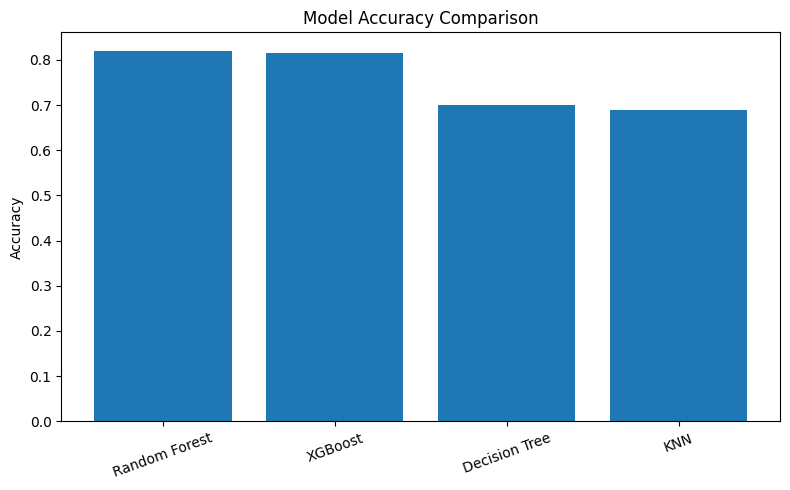

In [3]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.savefig(GRAPH_DIR/"accuracy_comparison.png")
plt.show()


## Confusion Matrices

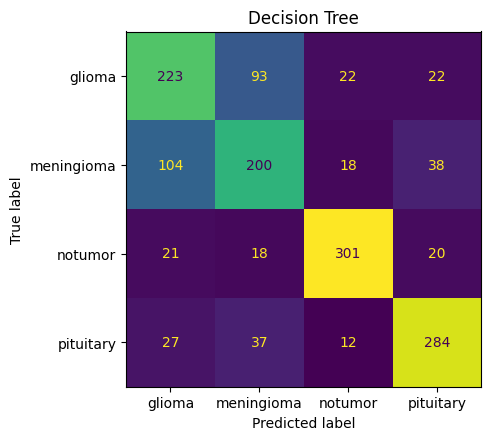


 Decision Tree
              precision    recall  f1-score   support

      glioma       0.59      0.62      0.61       360
  meningioma       0.57      0.56      0.56       360
     notumor       0.85      0.84      0.84       360
   pituitary       0.78      0.79      0.78       360

    accuracy                           0.70      1440
   macro avg       0.70      0.70      0.70      1440
weighted avg       0.70      0.70      0.70      1440



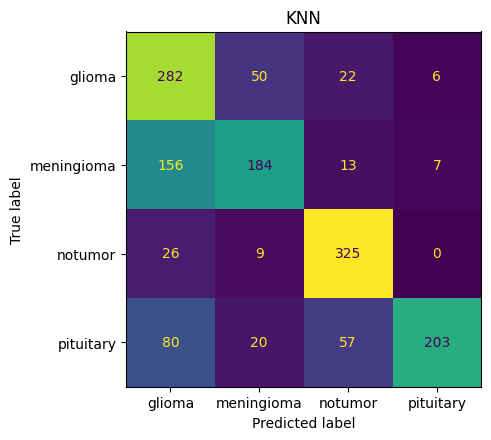


 KNN
              precision    recall  f1-score   support

      glioma       0.52      0.78      0.62       360
  meningioma       0.70      0.51      0.59       360
     notumor       0.78      0.90      0.84       360
   pituitary       0.94      0.56      0.70       360

    accuracy                           0.69      1440
   macro avg       0.73      0.69      0.69      1440
weighted avg       0.73      0.69      0.69      1440



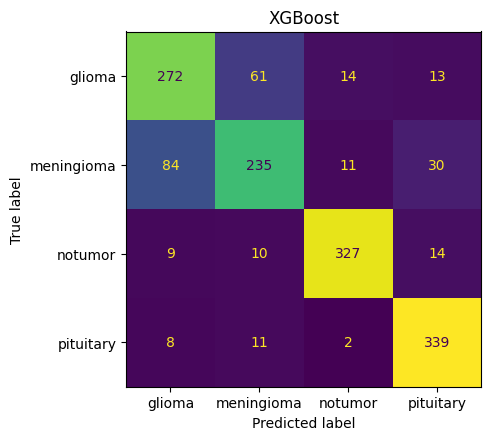


 XGBoost
              precision    recall  f1-score   support

      glioma       0.73      0.76      0.74       360
  meningioma       0.74      0.65      0.69       360
     notumor       0.92      0.91      0.92       360
   pituitary       0.86      0.94      0.90       360

    accuracy                           0.81      1440
   macro avg       0.81      0.81      0.81      1440
weighted avg       0.81      0.81      0.81      1440



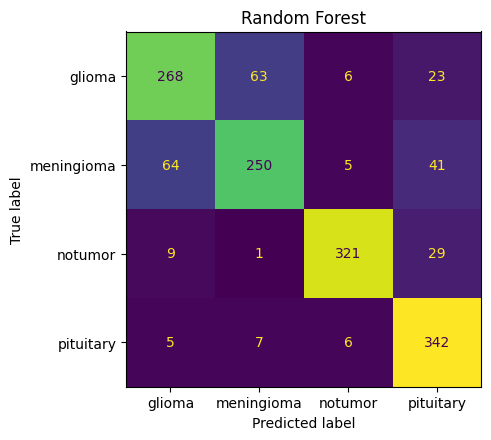


 Random Forest
              precision    recall  f1-score   support

      glioma       0.77      0.74      0.76       360
  meningioma       0.78      0.69      0.73       360
     notumor       0.95      0.89      0.92       360
   pituitary       0.79      0.95      0.86       360

    accuracy                           0.82      1440
   macro avg       0.82      0.82      0.82      1440
weighted avg       0.82      0.82      0.82      1440



In [4]:
for name, model in models.items():
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    fig, ax = plt.subplots(figsize=(5,5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoder.classes_
    ).plot(ax=ax, colorbar=False)

    plt.title(name)
    plt.tight_layout()
    plt.savefig(GRAPH_DIR/f"{name.lower().replace(' ','_')}_cm.png")
    plt.show()

    print("\n", name)
    print(classification_report(y_test,pred,target_names=encoder.classes_))


## Best Model

In [5]:
best = results_df.iloc[0]
print("Best Performing Model")
print(best)

with open(OUTPUT_DIR/"best_model.txt","w") as f:
    f.write(best["Model"])


Best Performing Model
Model        Random Forest
Accuracy          0.820139
Precision         0.822323
Recall            0.820139
F1 Score          0.818392
Name: 3, dtype: object


## Conclusion

The trained models were evaluated using multiple performance metrics. Based on the comparison, the highest-performing model should be selected for the prediction pipeline. Although Random Forest is the expected final model for this project, the final choice should be based on the evaluation results obtained from this notebook.


## Interview Notes

- Why compare multiple models?
- Why use weighted Precision, Recall and F1-score?
- What does a confusion matrix tell us?
- Why use ROC curves in multiclass classification?
- Why is the final model chosen based on evaluation metrics instead of assumptions?
